#Student name: Aayush Badu



#**Student** id: 2438453

# PART 1: Image Classification (CNN).

## 1. Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import random
from PIL import Image

## 2. Directory

In [8]:
test_dir = "/content/drive/MyDrive/AIML/Fruit Classification/Test"
train_dir = "/content/drive/MyDrive/AIML/Fruit Classification/Train"

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Understanding Data & Visualization


### Classes

In [10]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 5 classes: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']


### Checking Corrupted Images.

In [11]:
corrupted = []

for cls in class_names:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Class Count Balance

In [12]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
Banana                              1422
Cherry                              1222
Grape                               1468
Mango                                908
Peach                               1222


### Select Random Images for Visualization

In [13]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

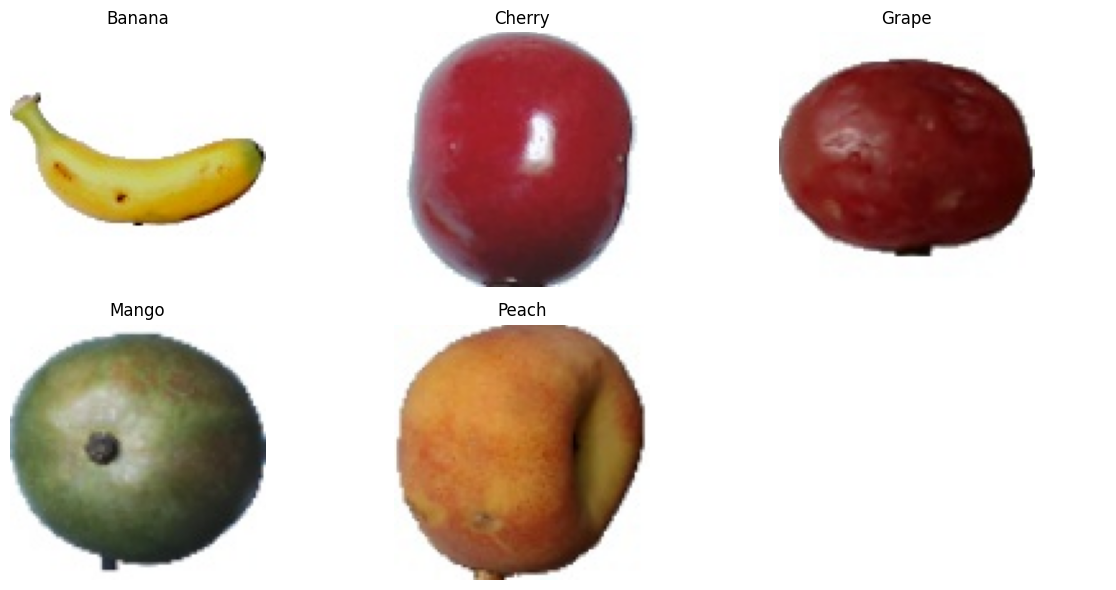

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

## Data Preprocessing and Generation

In [15]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [18]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.
Found 5 files belonging to 5 classes.


In [19]:
print(f"Contents of {test_dir}:")
files_in_test_dir = os.listdir(test_dir)
if files_in_test_dir:
    print(files_in_test_dir)
else:
    print("The directory is empty or does not exist.")

Contents of /content/drive/MyDrive/AIML/Fruit Classification/Test:
['Mango', 'Banana', 'Peach', 'Grape', 'Cherry']


In [20]:
data_augmentation_layers = [
     layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

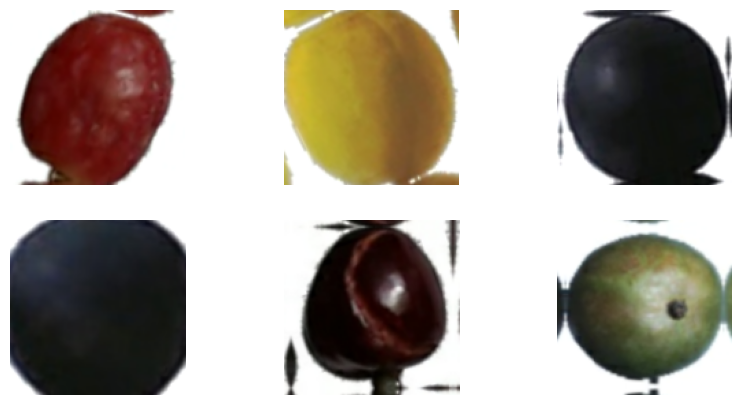

In [21]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        augmented = images[i]
        for layer in data_augmentation_layers:
            augmented = layer(augmented)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.axis("off")

In [26]:
normalization_layer = layers.Rescaling(1./255)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = len(train_ds.class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    *data_augmentation_layers,

    normalization_layer,

    # CNN Layers
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])



In [27]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # IMPORTANT CHANGE
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,141 (12.65 MB)

 Trainable params: 3,315,141 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.8773 - loss: 0.3353 - val_accuracy: 0.9992 - val_loss: 0.0070
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 189ms/step - accuracy: 0.9944 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 4.5651e-04
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 160ms/step - accuracy: 0.9864 - loss: 0.0477 - val_accuracy: 0.8686 - val_loss: 0.3593
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9551 - loss: 0.1521 - val_accuracy: 0.9992 - val_loss: 0.0047
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.9968 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 2.6963e-04
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.9988 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.9946 - loss: 0.0217 - val_accuracy: 0.9952 - val_loss: 0.0139
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 169ms/step - accuracy: 0.9806 -

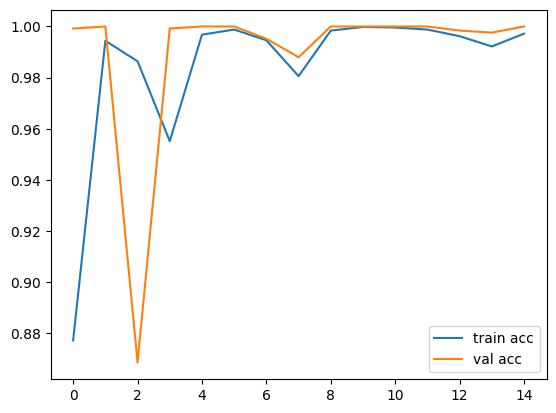

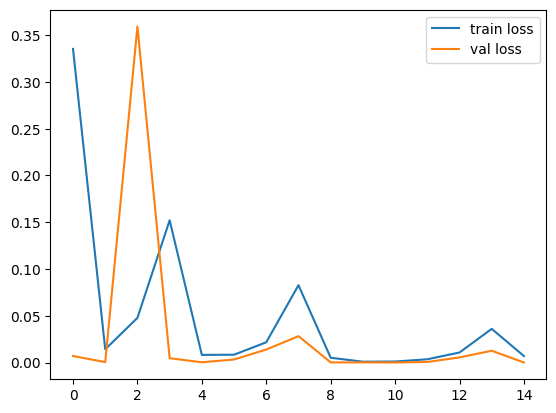

In [28]:
plt.plot(history_baseline.history['accuracy'], label='train acc')
plt.plot(history_baseline.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_baseline.history['loss'], label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [29]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = baseline_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



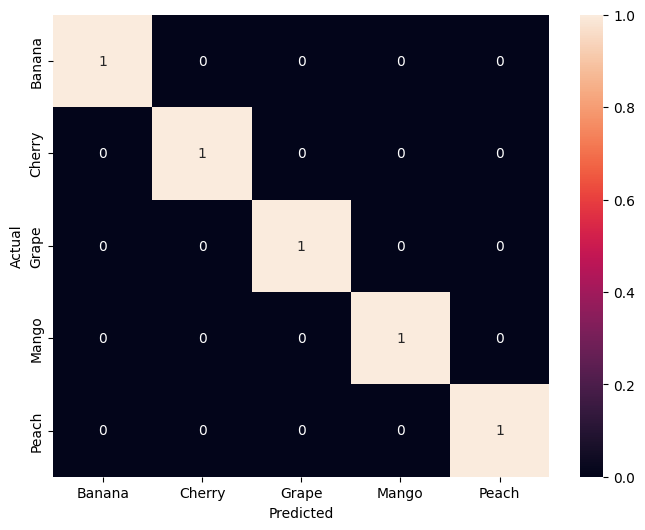

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Deeper Model

In [31]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(train_ds.class_names)

deep_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # ✅ Data Augmentation (same as before)
    *data_augmentation_layers,

    # ✅ Normalize
    layers.Rescaling(1./255),

    # 🔹 Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Extra Depth (important for assignment)
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Fully Connected
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,978,213 (11.36 MB)

 Trainable params: 2,976,741 (11.36 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [33]:
history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 154ms/step - accuracy: 0.8474 - loss: 0.4467 - val_accuracy: 0.2508 - val_loss: 2.1829
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.9077 - loss: 0.2913 - val_accuracy: 0.6066 - val_loss: 1.5039
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 188ms/step - accuracy: 0.9626 - loss: 0.1266 - val_accuracy: 0.4279 - val_loss: 3.6521
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 150ms/step - accuracy: 0.9760 - loss: 0.0879 - val_accuracy: 0.7893 - val_loss: 0.5386
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.9714 - loss: 0.0864 - val_accuracy: 0.8974 - val_loss: 0.2882
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.9708 - loss: 0.0866 - val_accuracy: 0.9655 - val_loss: 0.0782
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.9856 - loss: 0.0487 - val_accuracy: 0.9960 - val_loss: 0.0110
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.9908 - loss: 0

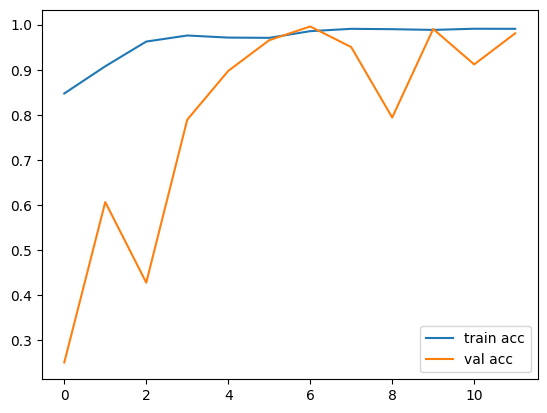

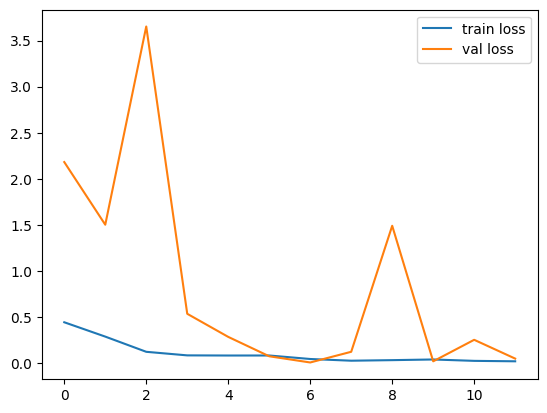

In [34]:
plt.plot(history_deep.history['accuracy'], label='train acc')
plt.plot(history_deep.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_deep.history['loss'], label='train loss')
plt.plot(history_deep.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [35]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = deep_model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



SGD

In [36]:
from tensorflow.keras.optimizers import SGD

deep_model_sgd = keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deep_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.7423 - loss: 0.7427 - val_accuracy: 0.1867 - val_loss: 7.3223
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.8624 - loss: 0.3915 - val_accuracy: 0.3590 - val_loss: 6.3366
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.9219 - loss: 0.2332 - val_accuracy: 0.6595 - val_loss: 1.4823
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.9614 - loss: 0.1244 - val_accuracy: 0.6683 - val_loss: 1.6679
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - accuracy: 0.9676 - loss: 0.1045 - val_accuracy: 0.7500 - val_loss: 0.9375


# Part 2: Fine Tuning

In [37]:
IMG_SIZE = 224

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

Found 6242 files belonging to 5 classes.
Using 4994 files for training.
Found 6242 files belonging to 5 classes.
Using 1248 files for validation.
Found 5 files belonging to 5 classes.


In [38]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
]

In [39]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # ❗ Remove original classifier
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [40]:
base_model.trainable = False

In [41]:
num_classes = len(train_ds.class_names)

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    *data_augmentation_layers,

    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [42]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,717 (9.26 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 239ms/step - accuracy: 0.9604 - loss: 0.1153 - val_accuracy: 0.9992 - val_loss: 0.0050
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.9966 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 8.4568e-04
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.9956 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 2.6823e-04
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.9940 - loss: 0.0214 - val_accuracy: 1.0000 - val_loss: 1.4521e-04
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.9938 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 3.8938e-05
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.9970 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 1.7628e-05
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.9960 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 1.4783e-05
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - ac

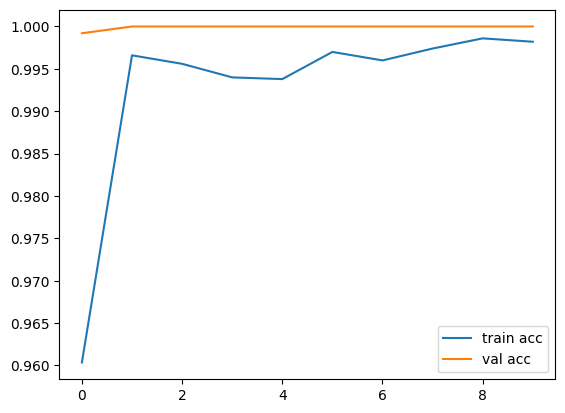

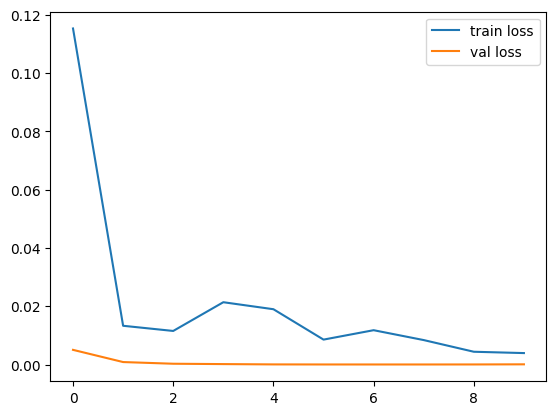

In [44]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [46]:
base_model.trainable = True

# Freeze lower layers, train only top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [47]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # ⚠️ smaller LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.9790 - loss: 0.0707 - val_accuracy: 1.0000 - val_loss: 1.9943e-04
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9902 - loss: 0.0317 - val_accuracy: 1.0000 - val_loss: 2.9226e-04
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.9916 - loss: 0.0203 - val_accuracy: 1.0000 - val_loss: 8.8693e-05
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.9928 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 8.4997e-06
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - accuracy: 0.9952 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 3.9240e-06
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - accuracy: 0.9950 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 3.3625e-06
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.9962 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 9.9674e-06
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step 

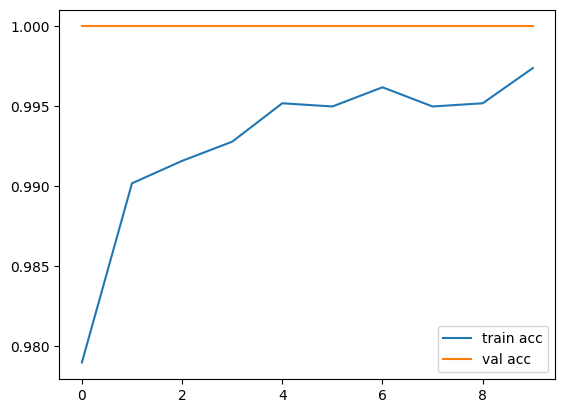

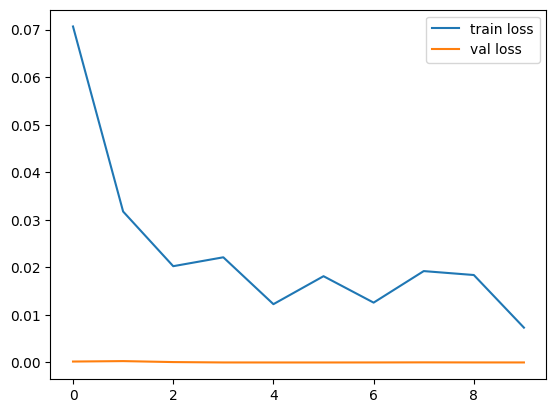

In [49]:
plt.plot(history_fine.history['accuracy'], label='train acc')
plt.plot(history_fine.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history_fine.history['loss'], label='train loss')
plt.plot(history_fine.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [50]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)

class_names = test_ds.class_names

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00         1
      Cherry       1.00      1.00      1.00         1
       Grape       1.00      1.00      1.00         1
       Mango       1.00      1.00      1.00         1
       Peach       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [51]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0
